In [10]:
import numpy as np
import pandas as pd


In [13]:
df = pd.read_csv("../Data/Churn_Modelling.csv")

In [14]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
df.drop(columns = ['RowNumber' , 'CustomerId' , 'Surname' ,] ,inplace=True)

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [18]:
df = pd.get_dummies(df,columns=['Geography' , 'Gender'] , drop_first=True)

In [19]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [20]:
X= df.drop(columns=['Exited'])
y= df['Exited'].values

from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [22]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [23]:
model = Sequential()

model.add(Dense(11,activation='sigmoid', input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(optimizer='Adam' , loss='binary_crossentropy',metrics=['accuracy'])

In [28]:
history=model.fit(X_train, y_train, batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2158 - loss: 0.9201 - val_accuracy: 0.5875 - val_loss: 0.6933
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - accuracy: 0.7831 - loss: 0.5994 - val_accuracy: 0.7969 - val_loss: 0.5394
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - accuracy: 0.7958 - loss: 0.5222 - val_accuracy: 0.7969 - val_loss: 0.5102
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - accuracy: 0.7958 - loss: 0.5086 - val_accuracy: 0.7969 - val_loss: 0.5043
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step - accuracy: 0.7958 - loss: 0.5055 - val_accuracy: 0.7969 - val_loss: 0.5023
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - accuracy: 0.7958 - loss: 0.5041 - val_accuracy: 0.7969 - val_loss: 0.5008
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.7958 - loss: 0.5031 - val_accuracy: 0.7969 - val_loss: 0.4995
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 527us/step - accuracy: 0.7958 - loss: 0.5

In [29]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step


In [30]:
y_pred


array([[0.2603178],
       [0.2603178],
       [0.2603178],
       ...,
       [0.2603178],
       [0.2656229],
       [0.2603178]], shape=(2000, 1), dtype=float32)

In [31]:
y_pred = y_pred.argmax(axis=-1)

In [32]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

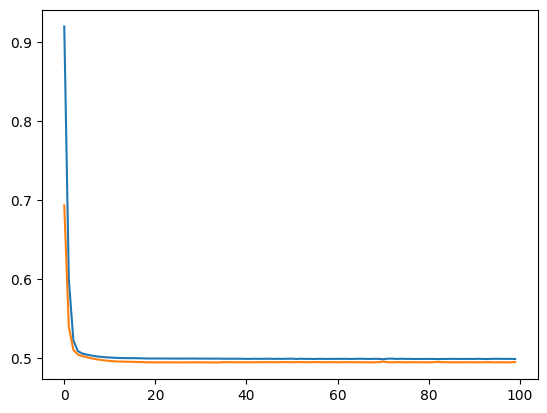

In [34]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


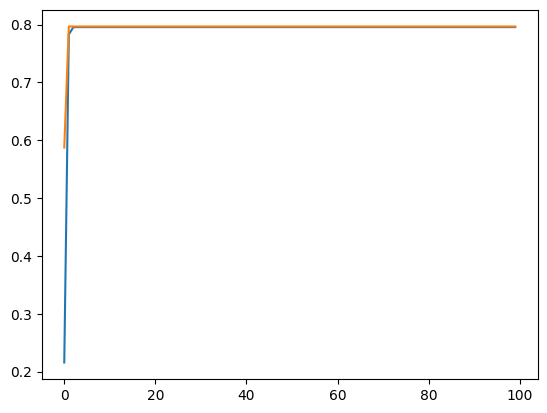

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])